In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import spatial



In [39]:
r_cols = ['use_id', 'movie_id', 'rating']
ratings = pd.read_csv("/home/beuren/Documentos/LAMIA-Bootcamp/card-11/data/u.data", sep= '\t', names = r_cols, usecols=range(3))
ratings.head()

,use_id,movie_id,rating
0,0,50,5
1,0,172,5
2,0,133,1
3,196,242,3
4,186,302,3


In [40]:
movieProperties = ratings.groupby('movie_id').agg({'rating': [np.size, np.mean]})
# agrupa por id_movie e depois calcula o rating com tamanho e media
movieProperties.head()
#mostra as 5 primeiras linhas

/tmp/ipykernel_104150/2024563988.py:1: FutureWarning: The provided callable <function mean at 0x7673887971a0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  movieProperties = ratings.groupby('movie_id').agg({'rating': [np.size, np.mean]})


rating          
           size      mean
movie_id                 
1           452  3.878319
2           131  3.206107
3            90  3.033333
4           209  3.550239
5            86  3.302326

In [41]:
mrating = pd.DataFrame(movieProperties['rating']['size'])
# transforma size em um dataframe 
normalrating = mrating.apply(lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)))
# a lambda acima e aplicada para cada filme que por sua vez, é nomalizado para ficar no intervalo de 0-1 sendo melhor de visualizar e melhor para o modelo
normalrating.head()

,size
movie_id,
1,0.773585
2,0.222985
3,0.152659
4,0.356775
5,0.145798


In [ ]:
movieDict = {}
with open('/home/beuren/Documentos/LAMIA-Bootcamp/card-11/data/u.item', encoding='latin-1') as f:
    # para todas as linhas separa o genero, nome e o id, colocando ao final no dicionario
    temp = ''
    for line in f:
        fields= line.rstrip('\n').split('|')
        movieID = int(fields[0])
        #pega a coluna 0
        name = fields[1]
        genrs = fields[5:25]

        genrs = list(map(int, genrs))

        movieDict[movieID] = (name, genrs, normalrating.loc[movieID].get('size'), movieProperties.loc[movieID].rating.get('mean'))
        # coloca no dicionario a quantidade de avaliações e a avaliação media 

In [43]:
movieDict[2]

('GoldenEye (1995)',
 [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
 np.float64(0.22298456260720412),
 np.float64(3.2061068702290076))

In [ ]:
# a funcao recebe dois ids e calcula a distancia entre eles, atraves do genero e da popularidade deles
def ComputeDistance(a,b):
    genrsA = a[1]
    genrsB = b[1]
    genrsDistance = spatial.distance.cosine(genrsA,genrsB)
    popularityA = a[2]
    popularityB = b[2]
    popularityDistance = abs(popularityA - popularityB)
    return genrsDistance + popularityDistance

ComputeDistance(movieDict[123],movieDict[456])


np.float64(0.6149228130360206)

In [45]:
print(movieDict[123])
print(movieDict[456])
#printa os dois casos utilizados

('Frighteners, The (1996)', [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], np.float64(0.1955403087478559), np.float64(3.234782608695652))
('Beverly Hills Ninja (1997)', [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], np.float64(0.08061749571183534), np.float64(2.3125))


In [46]:
import operator

def getNeighbors(movieID, k):
    distances= []
    for movie in movieDict:
        if(movie !=movieID):
            dist = ComputeDistance(movieDict[movieID],movieDict[movie])
            distances.append((movie, dist))
    distances.sort(key=operator.itemgetter(1))
    neighbors = []
    for x in range(k):
        neighbors.append(distances[x][0])
    return neighbors
     # esta função pega os vizinhos dado um numero K de vizinhos

In [47]:
listK=[]
listavRating=[]
# cria duas listas vazias para guardar o numero de Ks e as avaliações

In [48]:
for k in range(1,200,10):
    listK.append(k)
    avRating = 0
    neighbors = getNeighbors(1,k)
    for neighbor in neighbors:
        avRating+= movieDict[neighbor][3]
    # para cada um dos filmes faz uma media e guarda na lista
    av =avRating /float(k)
    listavRating.append(av)

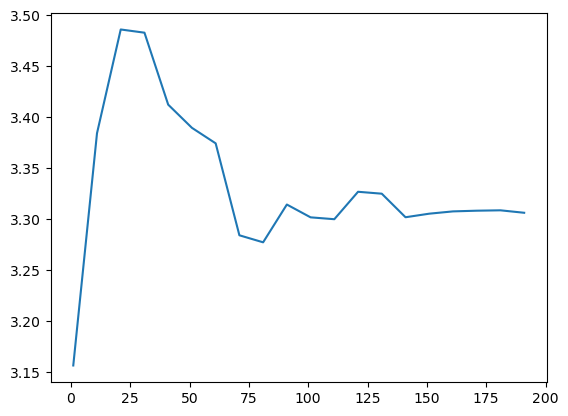

In [49]:
plt.plot(listK,listavRating)